In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

In [4]:
df = pd.read_json("results/results.json")
df

,original_text,simplified_text,flesch_reading_ease,flesch_kincaid_grade,smog_index,coleman_liau_index,automated_readability_index,dale_chall_readability_score,new_flesch_reading_ease,new_flesch_kincaid_grade,new_smog_index,new_coleman_liau_index,new_automated_readability_index,new_dale_chall_readability_score,mean_simple,mean_alpha,mean_stop_punct,new_mean_simple,new_mean_alpha,new_mean_filtered
0,“Ah! Senor Don Jose!” she cried. Don Jose fro...,“Ah! Senor Don Jose!” she cried. Don Jose fro...,73.926540,7.025014,9.494457,6.878234,7.615163,7.944427,75.823170,6.548887,9.340522,6.469009,6.981690,7.917131,0.000113,-0.004400,-0.004398,0.000391,-0.003916,-0.003911
1,"George Gordon Byron [1788-1824] ""THEY SPEAK O...","George Gordon Byron [1788-1824] ""THEY SPEAK O...",75.279925,8.957526,8.547743,7.559593,11.935538,8.865654,73.056697,9.062315,9.746453,7.739578,11.722636,8.990247,0.000653,-0.007231,-0.006696,0.001284,-0.006096,-0.005542
2,This even the whistler recognized after a few...,This even the whistler recognized after a mom...,74.399282,6.116042,9.594106,7.382570,6.952653,8.155189,77.569480,5.596174,9.176203,6.725747,6.346245,7.942757,-0.001218,-0.007696,-0.007652,-0.000640,-0.006630,-0.006571
3,"Bennet; ""and I am glad to find that you do no...","Bennet; ""and I am glad to find that you do no...",70.128559,7.452648,9.945355,7.492857,7.978168,7.964376,72.525117,6.917676,9.481441,6.901621,7.199382,7.881851,0.000138,-0.006190,-0.006589,0.000470,-0.005872,-0.006335
4,"For I disobeyed, not from a better choice, bu...","For I disobeyed, not from a choice, but from ...",67.180760,10.388324,11.122346,7.484791,12.329978,8.825317,68.329816,9.930640,11.222354,7.245078,11.611581,8.767690,0.000235,-0.008864,-0.008871,0.000934,-0.007451,-0.007452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"Medical Officer for the parishes of Grimpen, ...","Medical Officer for the parishes of Grimpen, ...",69.525814,8.566102,10.804464,7.848625,9.882360,8.390169,72.589724,7.858470,10.308745,7.258954,8.937714,8.199269,0.000171,-0.005102,-0.005130,0.000704,-0.004171,-0.004217
96,", B.A. 1839, M.A. 1842, D.C.L. 1863; barrister...",", B.A. 1839, M.A. 1842, D.C.L. 1863; barrister...",77.382214,4.780498,8.694205,6.306462,5.711456,14.285129,76.689309,4.849259,8.783252,6.338137,5.736227,14.473810,0.006902,0.001423,0.007995,0.007160,0.002045,0.008460
97,“Who is this for?” I asked. Hawberk explained...,“Who is this for?” I asked. Hawberk explained...,72.417442,6.985424,9.575205,7.651153,8.022729,8.909585,74.636369,6.519812,9.292342,7.162056,7.391261,8.871640,-0.000328,-0.004089,-0.004028,-0.000236,-0.004041,-0.003965
98,"In spite of his tininess, he was a capital wa...","In malevolence of his tininess, he was a capi...",63.960740,8.931510,11.596283,9.260990,10.546561,9.118435,68.801951,7.934585,10.974884,8.265957,9.241309,8.826962,0.001054,-0.004631,-0.004612,0.001763,-0.003261,-0.003233


In [61]:
means = df.mean(numeric_only=True)
means

flesch_reading_ease                 68.481221
flesch_kincaid_grade                 8.698938
smog_index                          10.351441
coleman_liau_index                   7.998331
automated_readability_index         10.308794
dale_chall_readability_score         8.807362
new_flesch_reading_ease             70.712629
new_flesch_kincaid_grade             8.139173
new_smog_index                      10.091441
new_coleman_liau_index               7.550392
new_automated_readability_index      9.535584
new_dale_chall_readability_score     8.710492
mean_simple                          0.000619
mean_alpha                          -0.005155
mean_stop_punct                     -0.004790
new_mean_simple                      0.001060
new_mean_alpha                      -0.004395
new_mean_filtered                   -0.004029
dtype: float64

## Score Comparisons

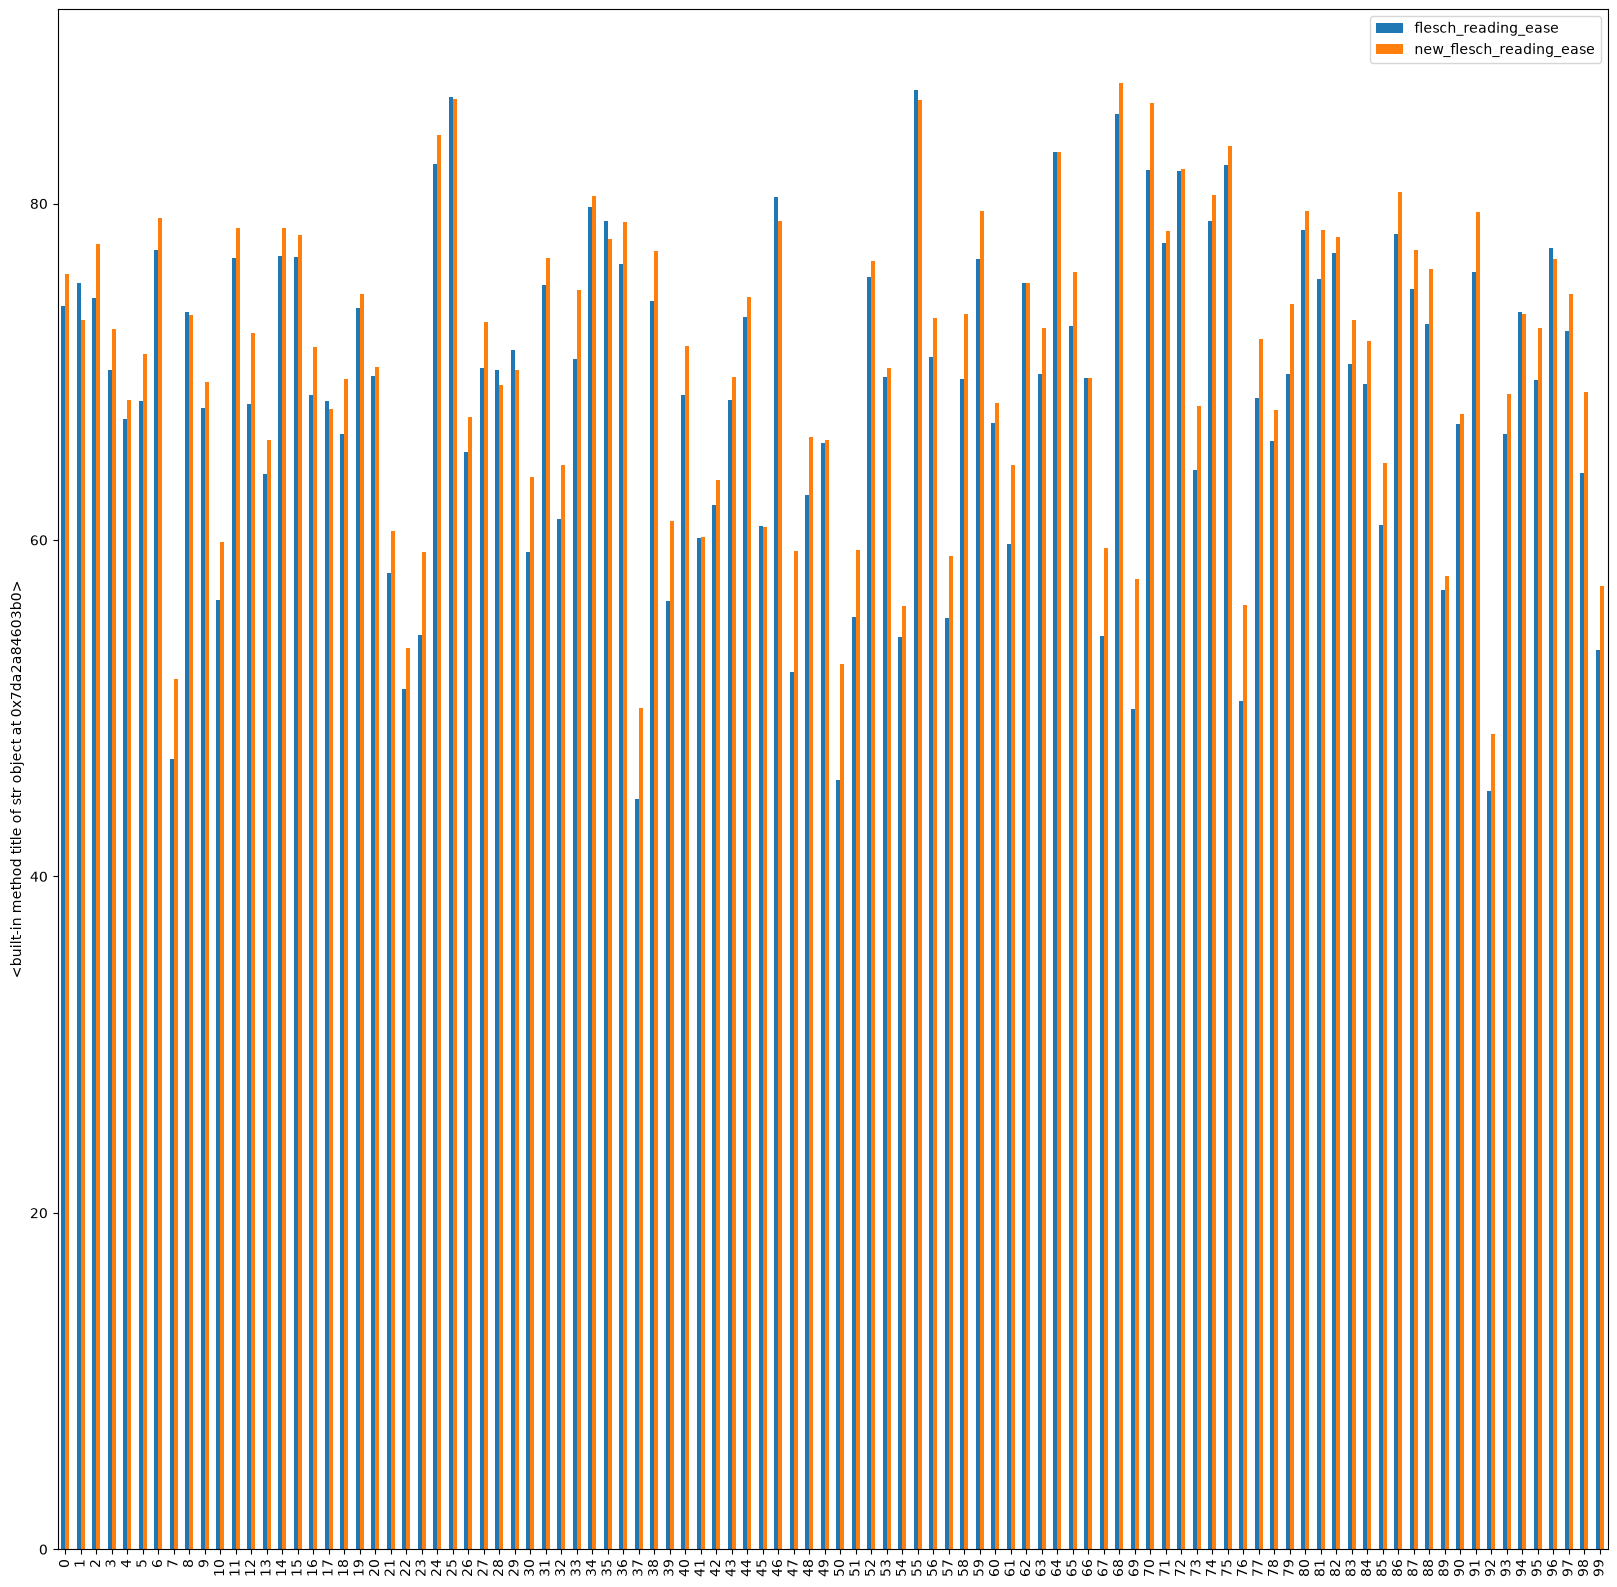

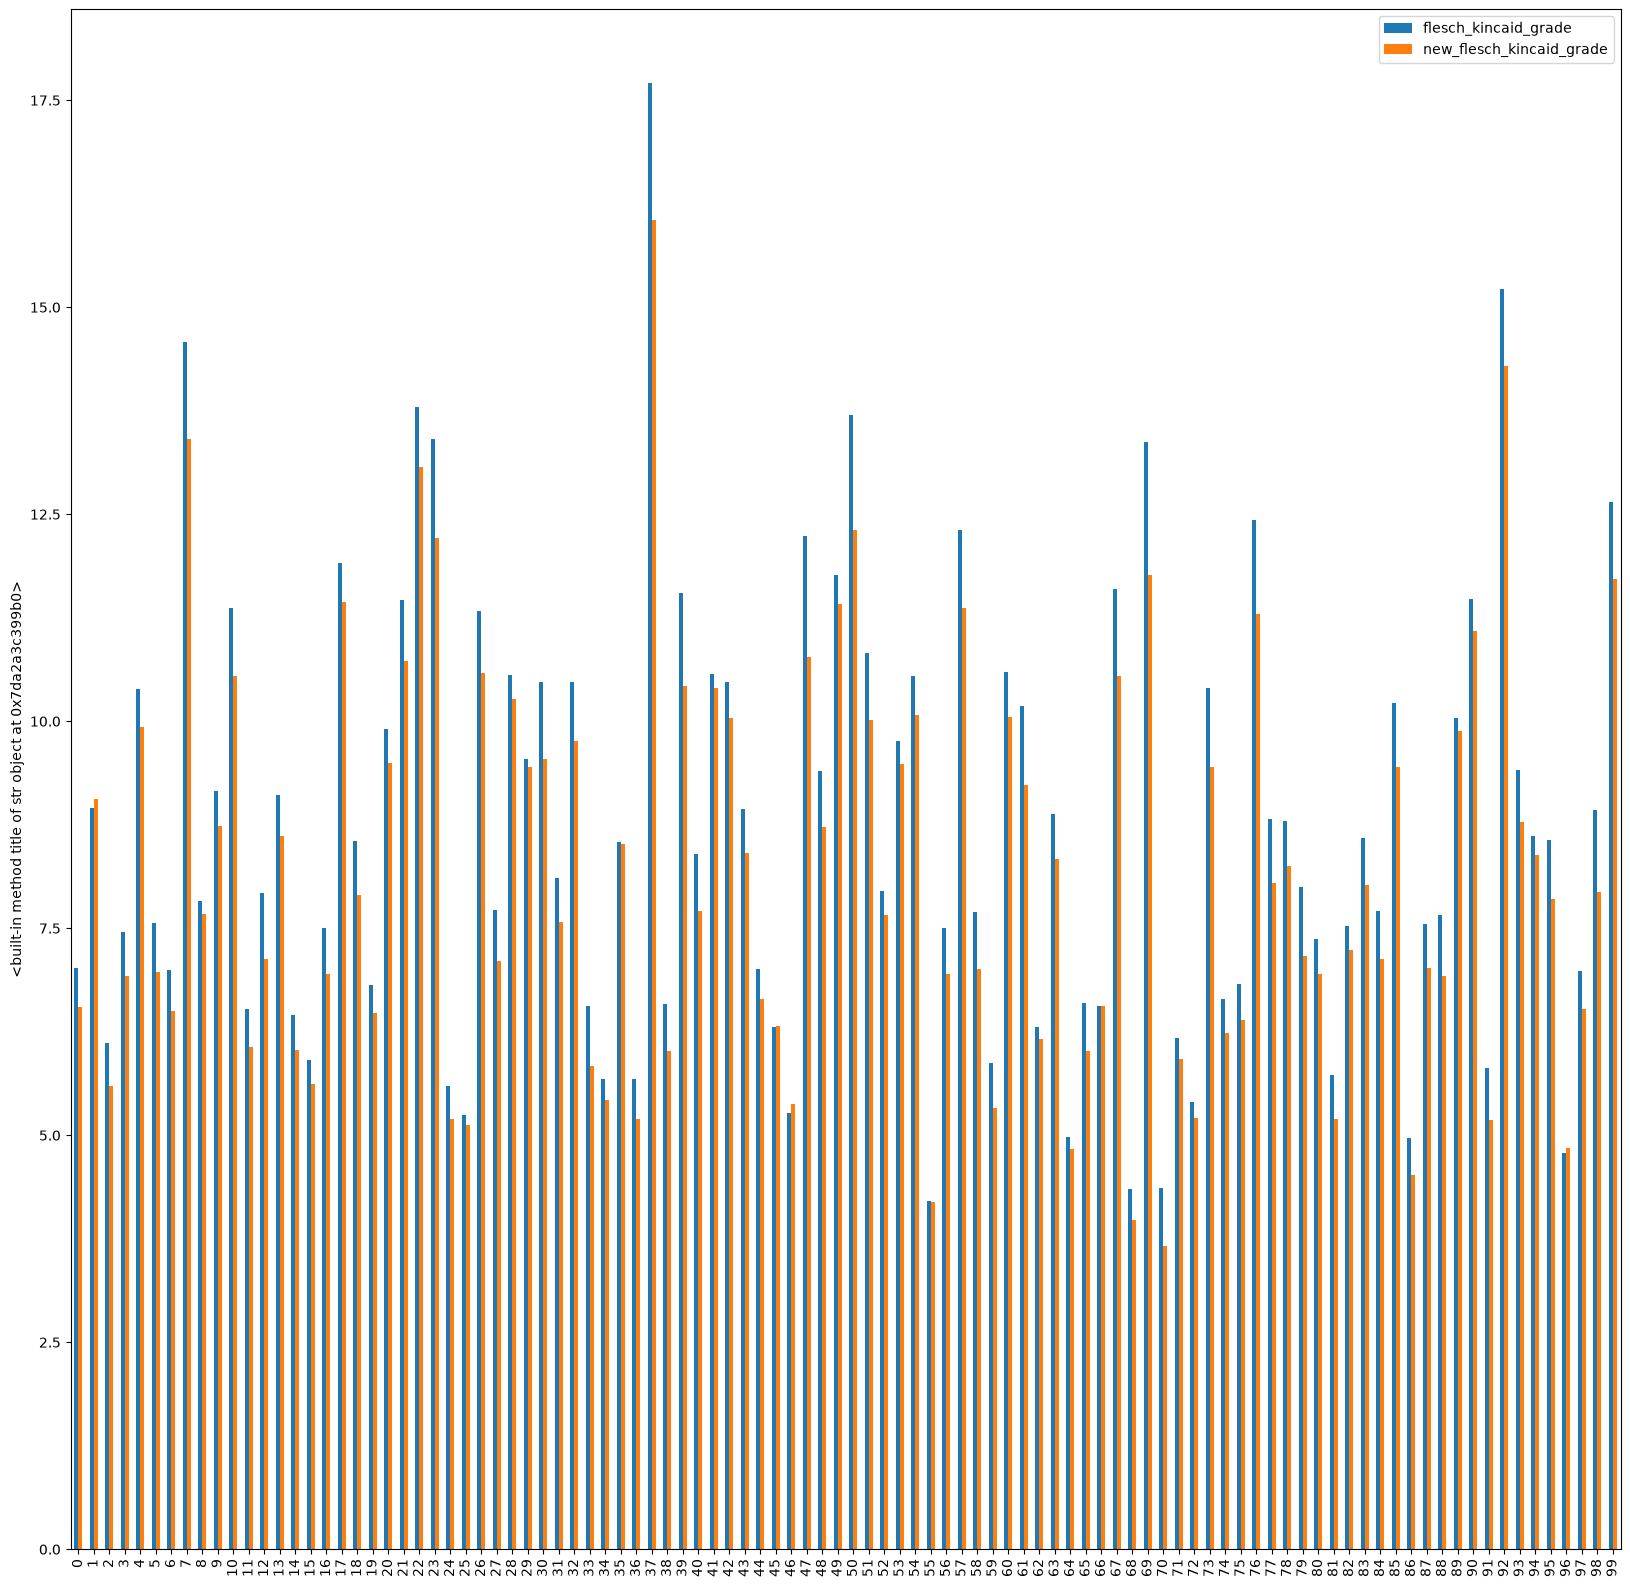

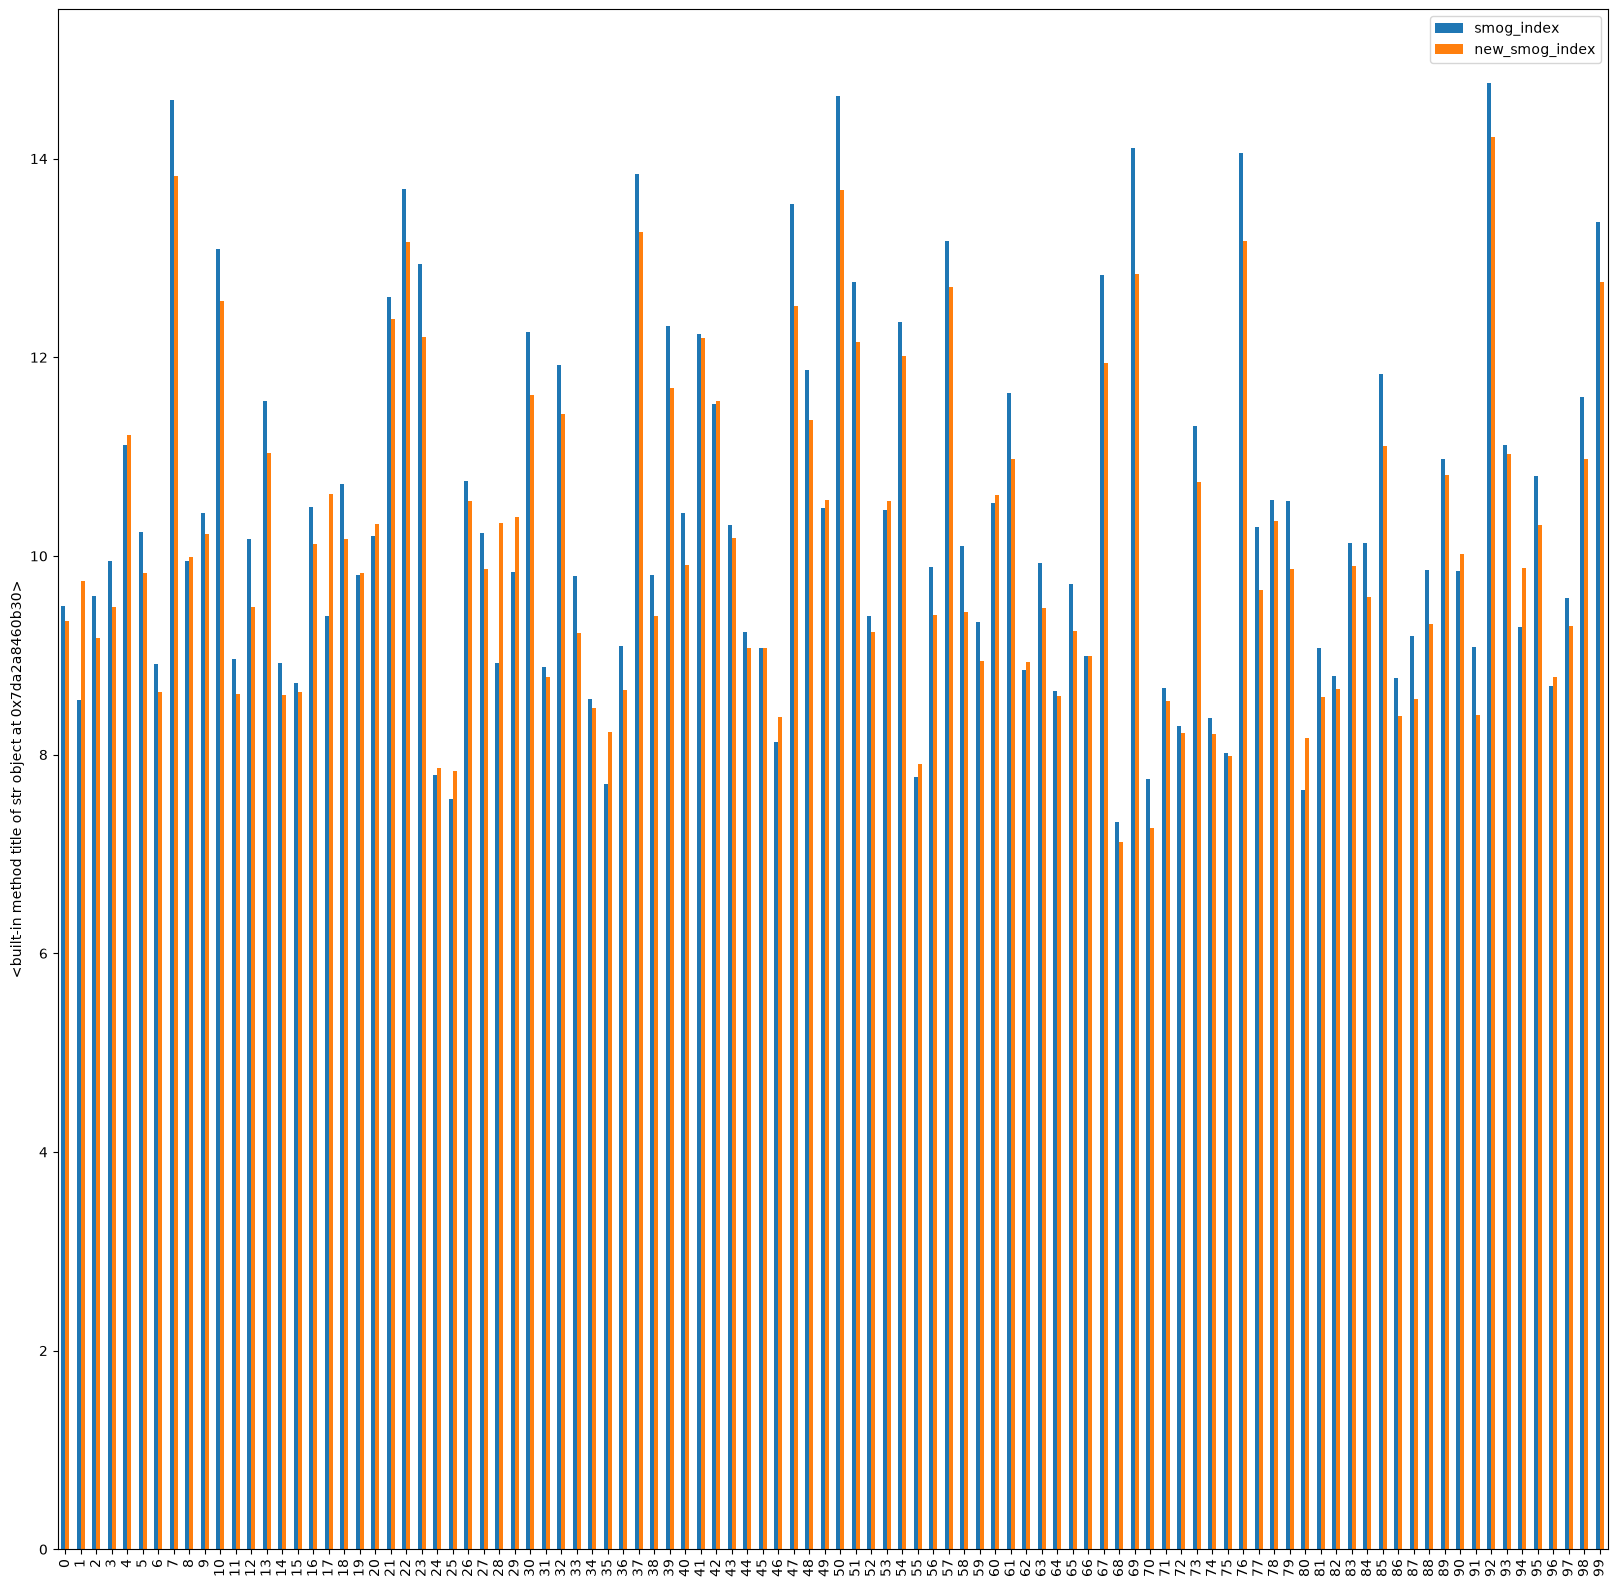

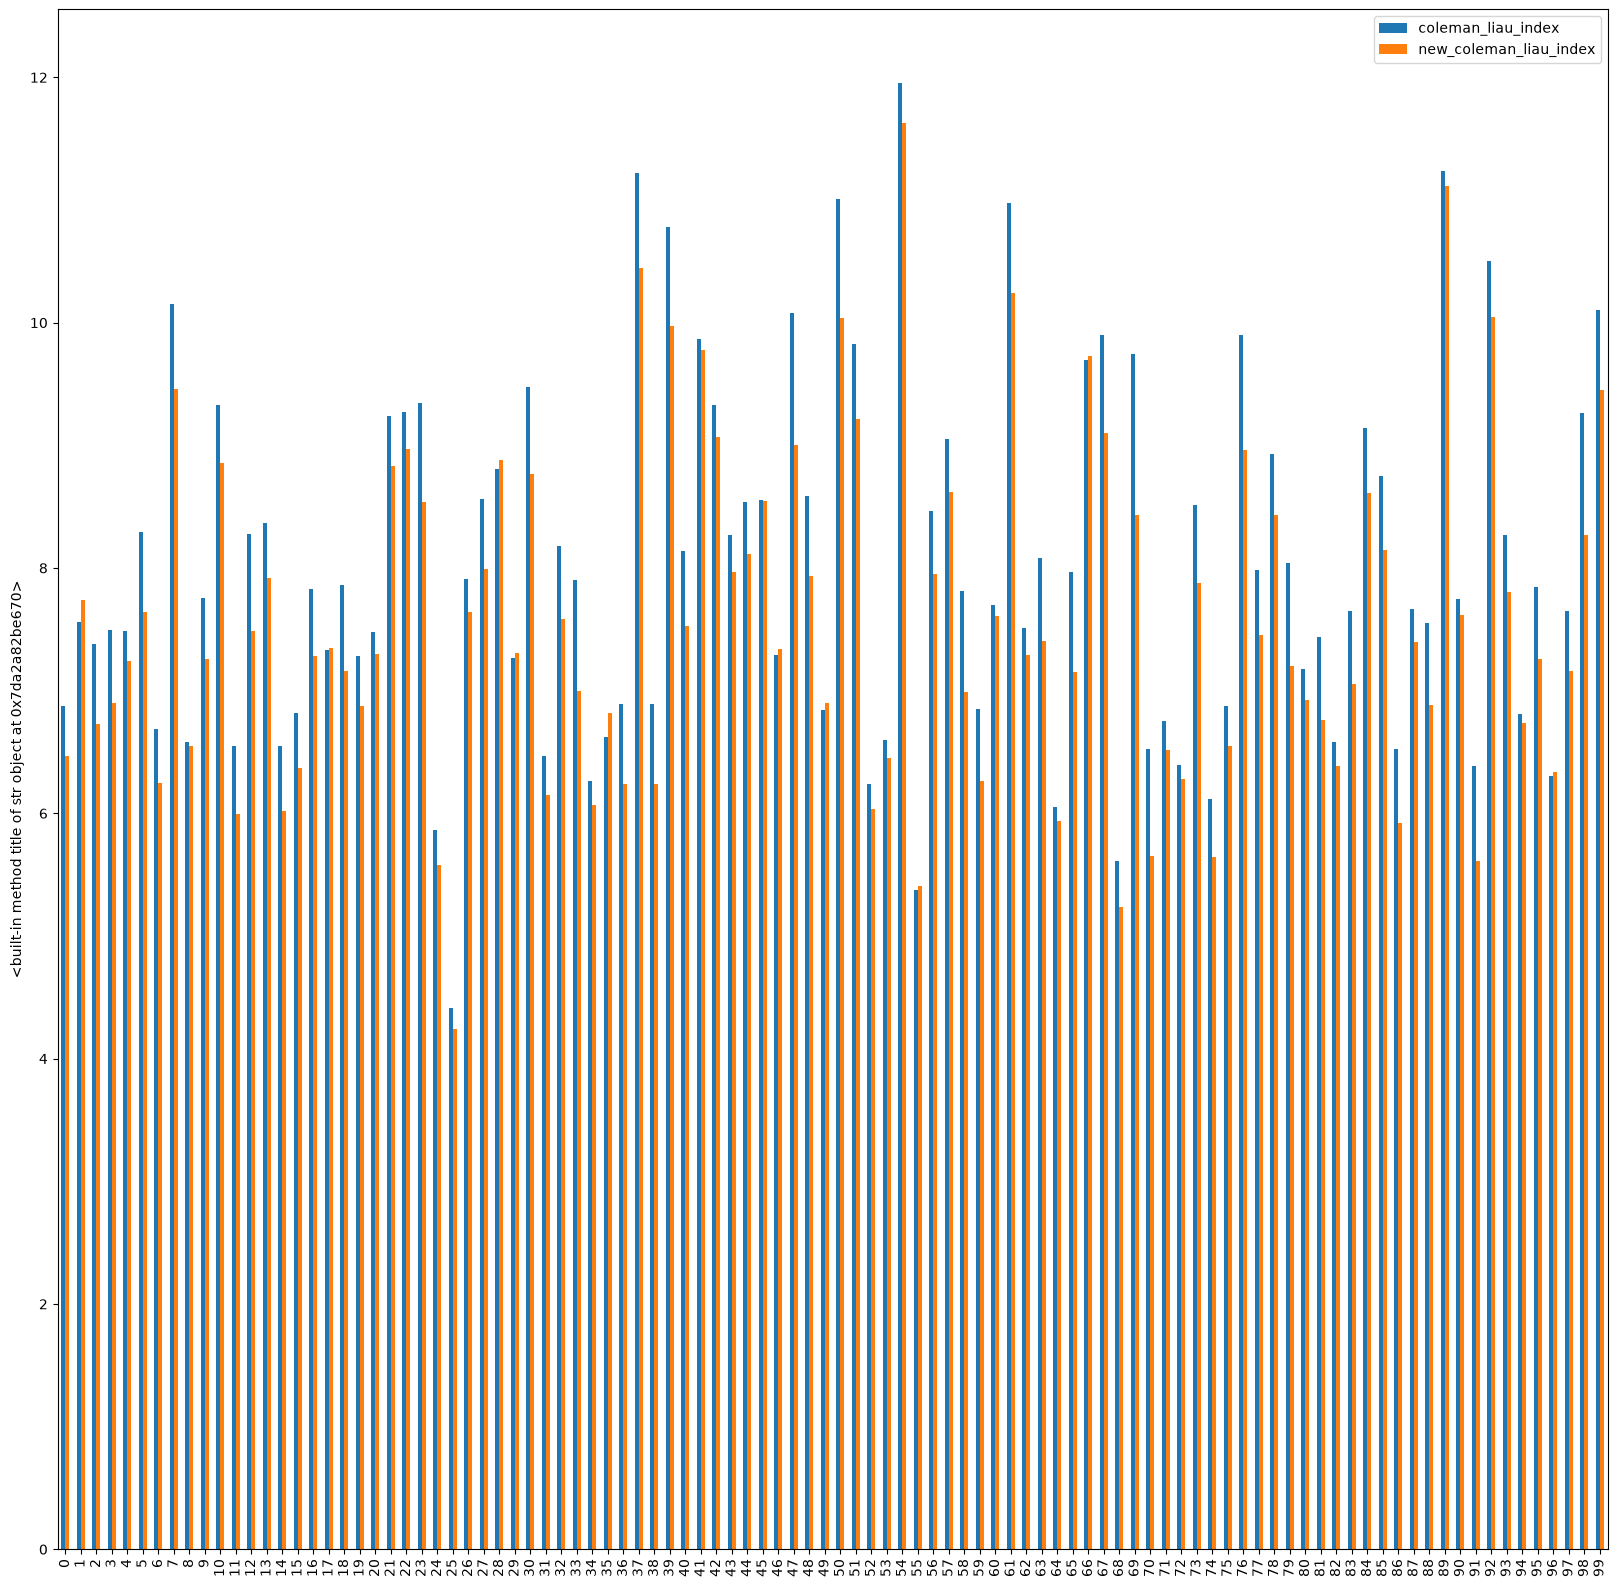

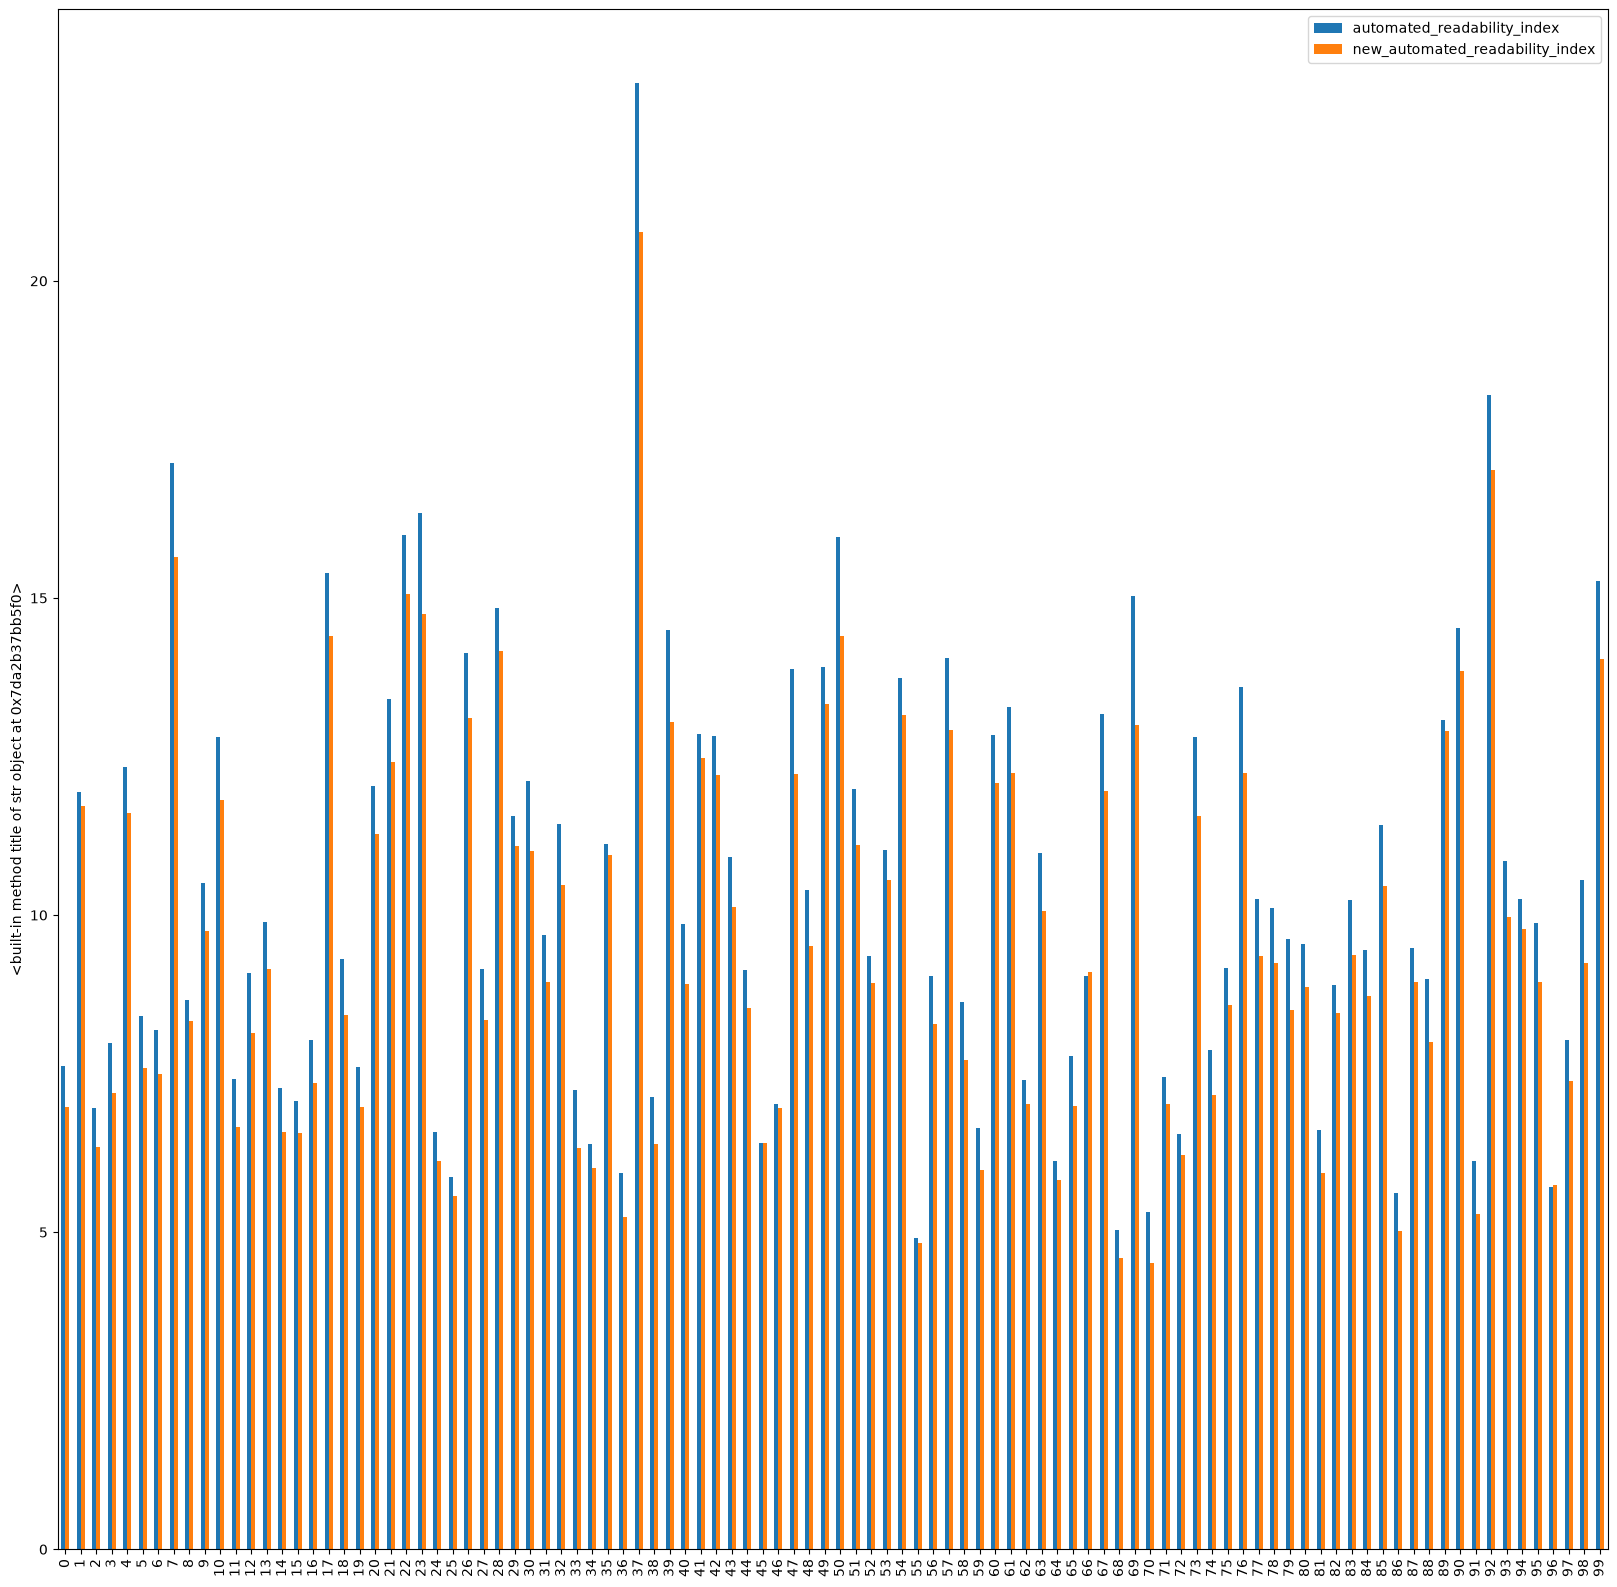

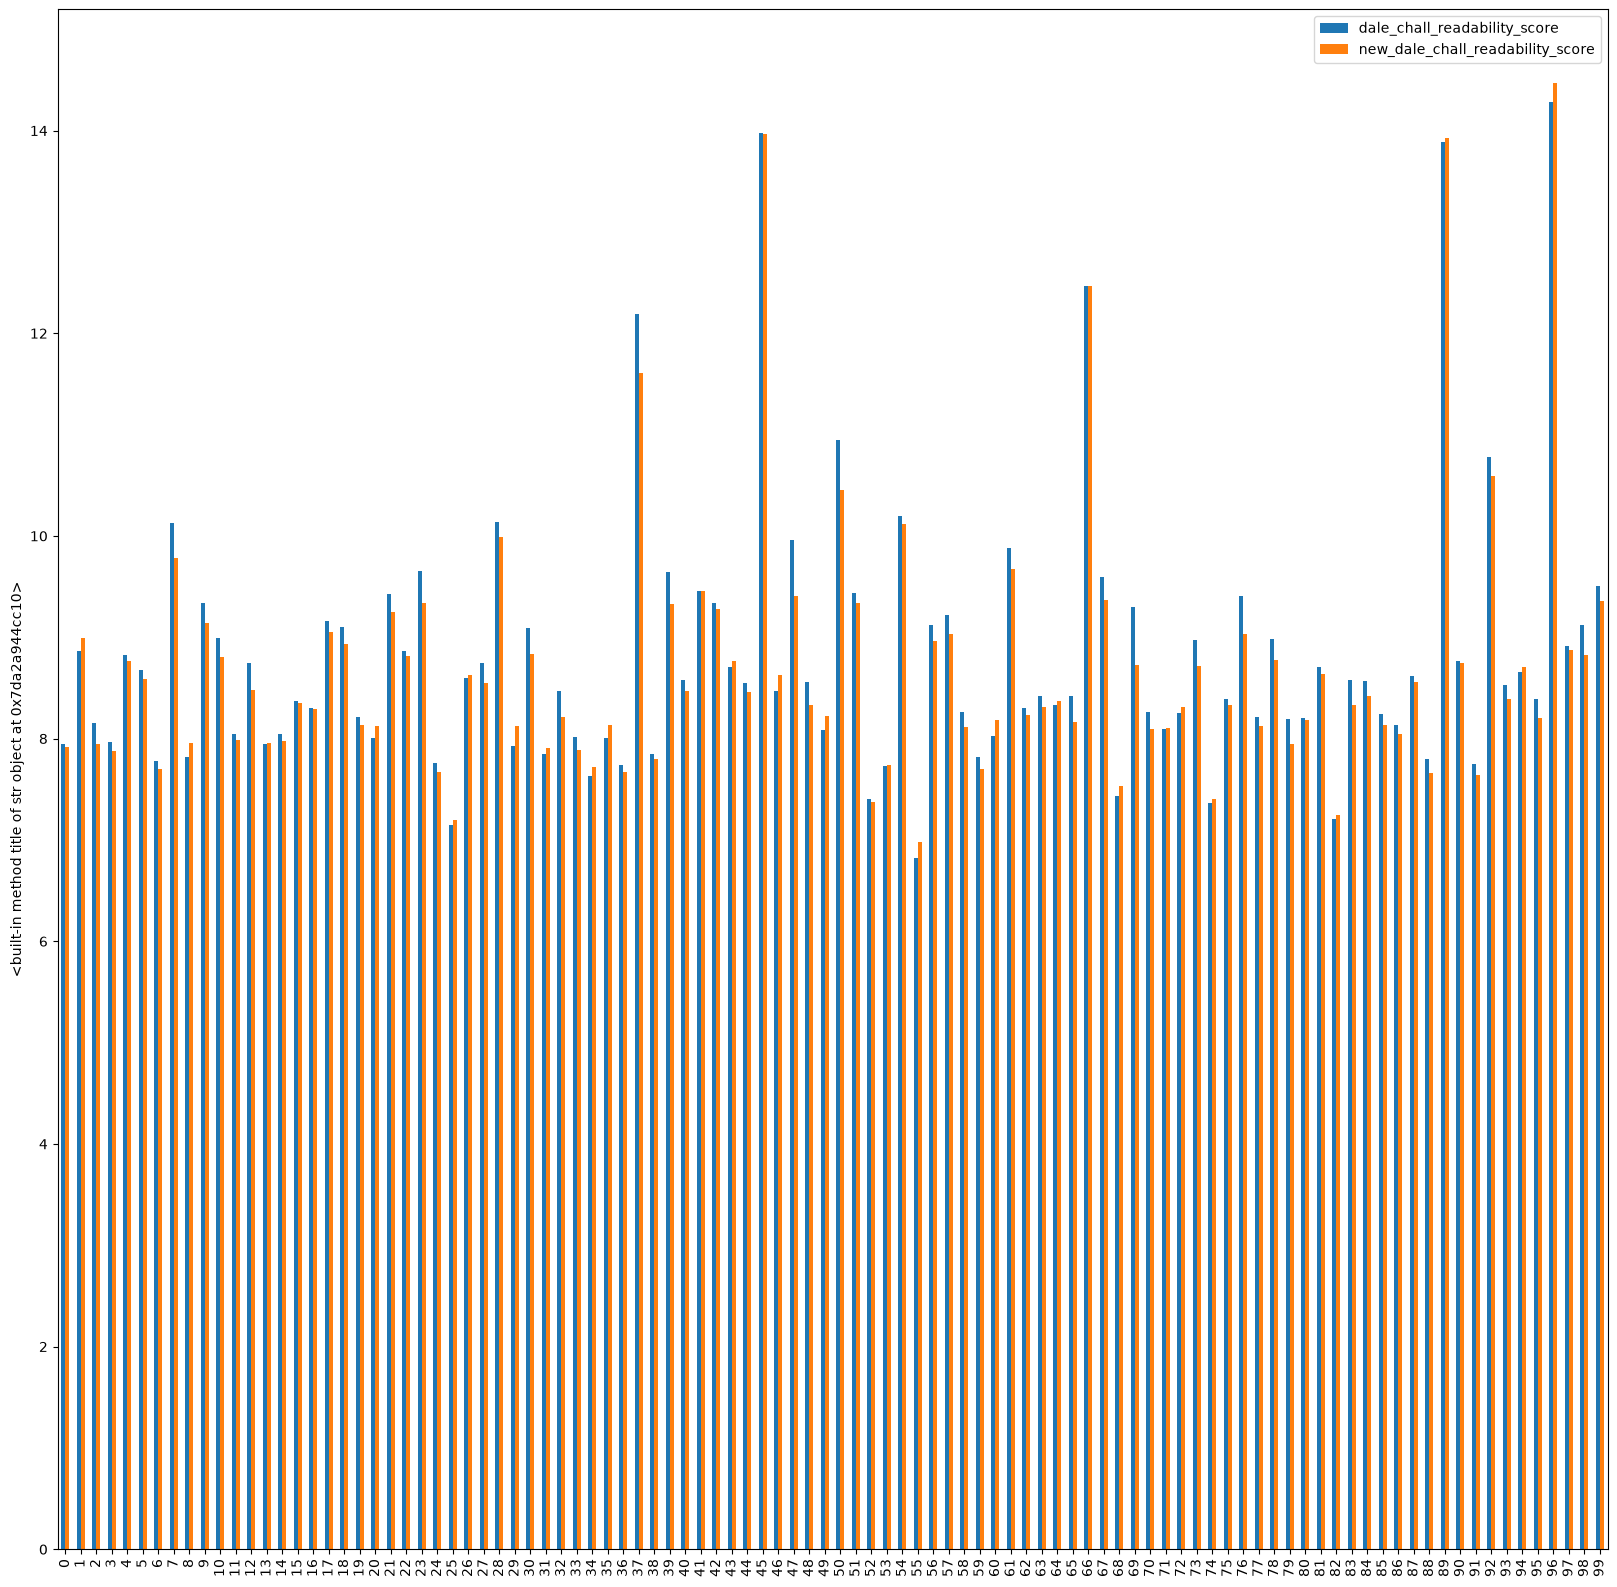

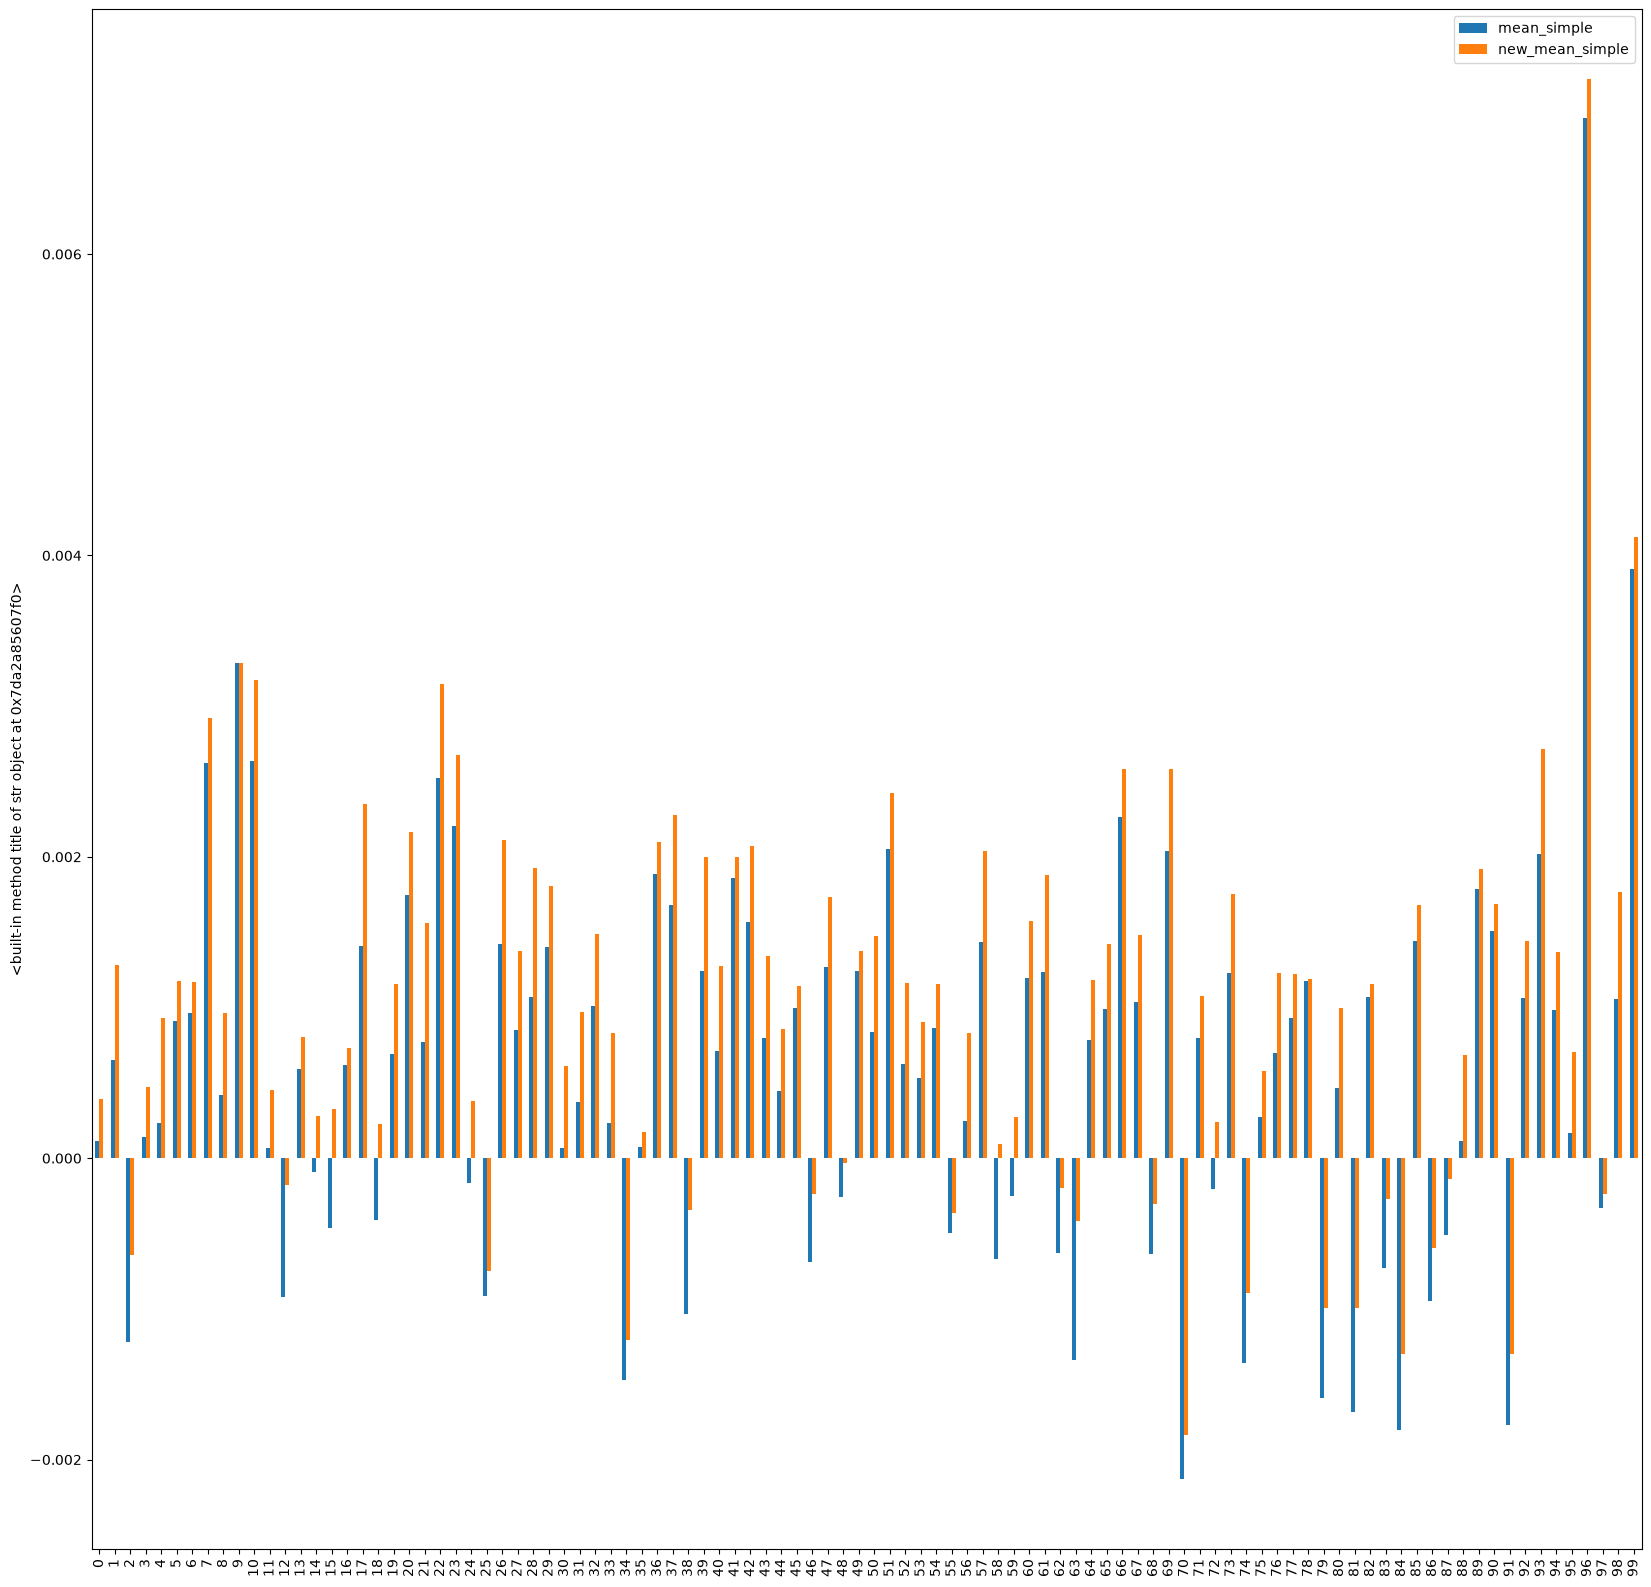

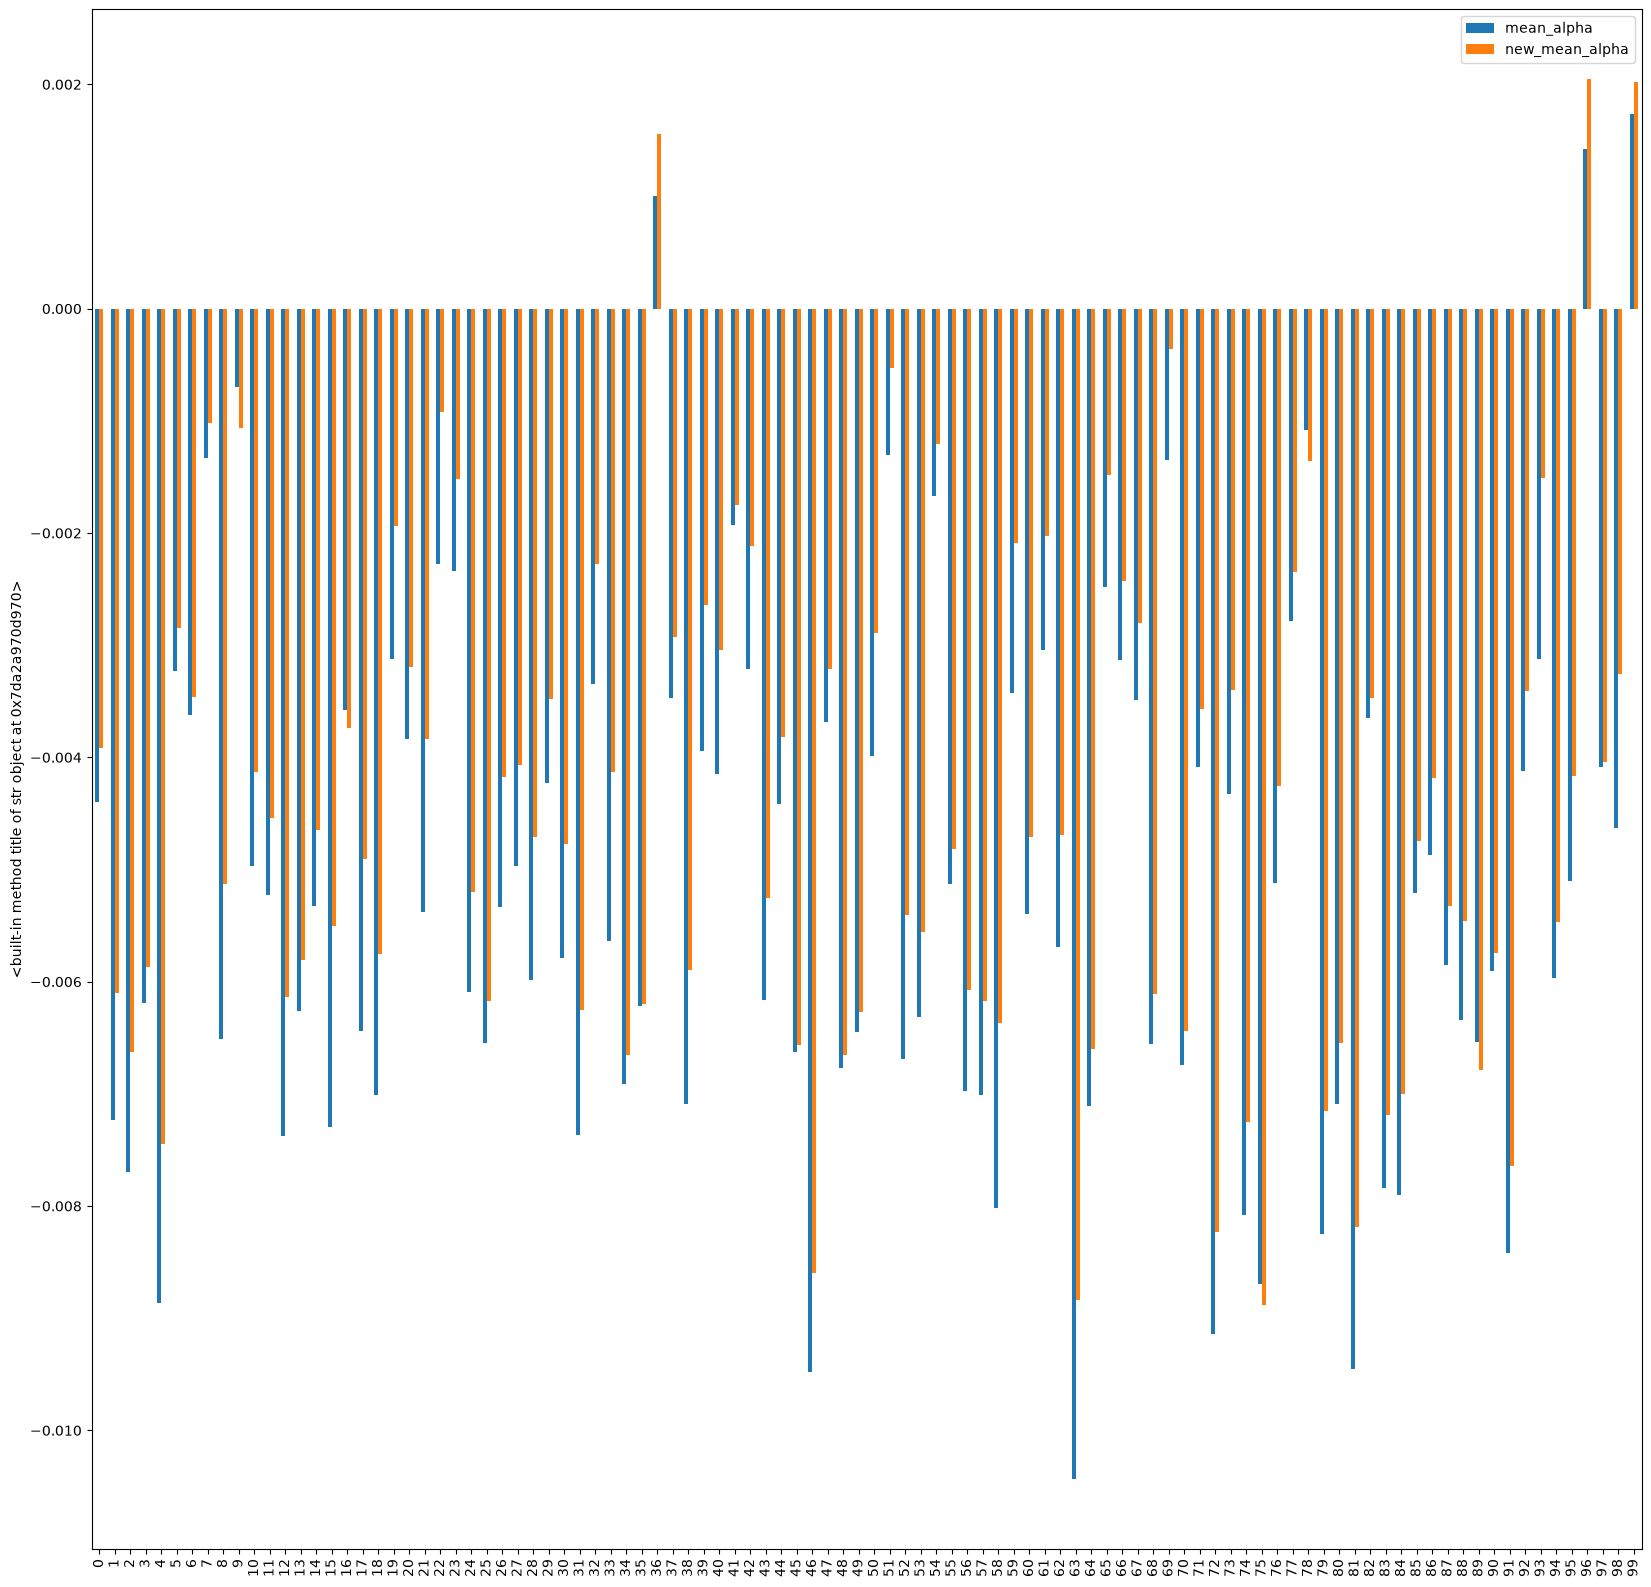

KeyError: "['new_mean_stop_punct'] not in index"

In [56]:
scores = ['flesch_reading_ease',
       'flesch_kincaid_grade', 'smog_index', 'coleman_liau_index',
       'automated_readability_index', 'dale_chall_readability_score', 'mean_simple', 'mean_alpha',
       'mean_stop_punct']
for score in scores:
    df.plot(y=[f"{score}", f"new_{score}"], kind="bar",figsize=(20,20))
    plt.ylabel(f"{score.title}")
    plt.show()

## 1. Correlations

In [38]:
corr_df = filtered_df.corr(numeric_only=True).dropna(how="all", axis=1).dropna(how="all")
pval = corr_df.corr(method=lambda x, y: pearsonr(x, y)[1], numeric_only=True).dropna(how="all", axis=1).dropna(how="all") - np.eye(*corr_df.shape)
pval_df = pval.map(lambda x: ''.join(['*' for t in [.05, .01, .001] if x<=t]))

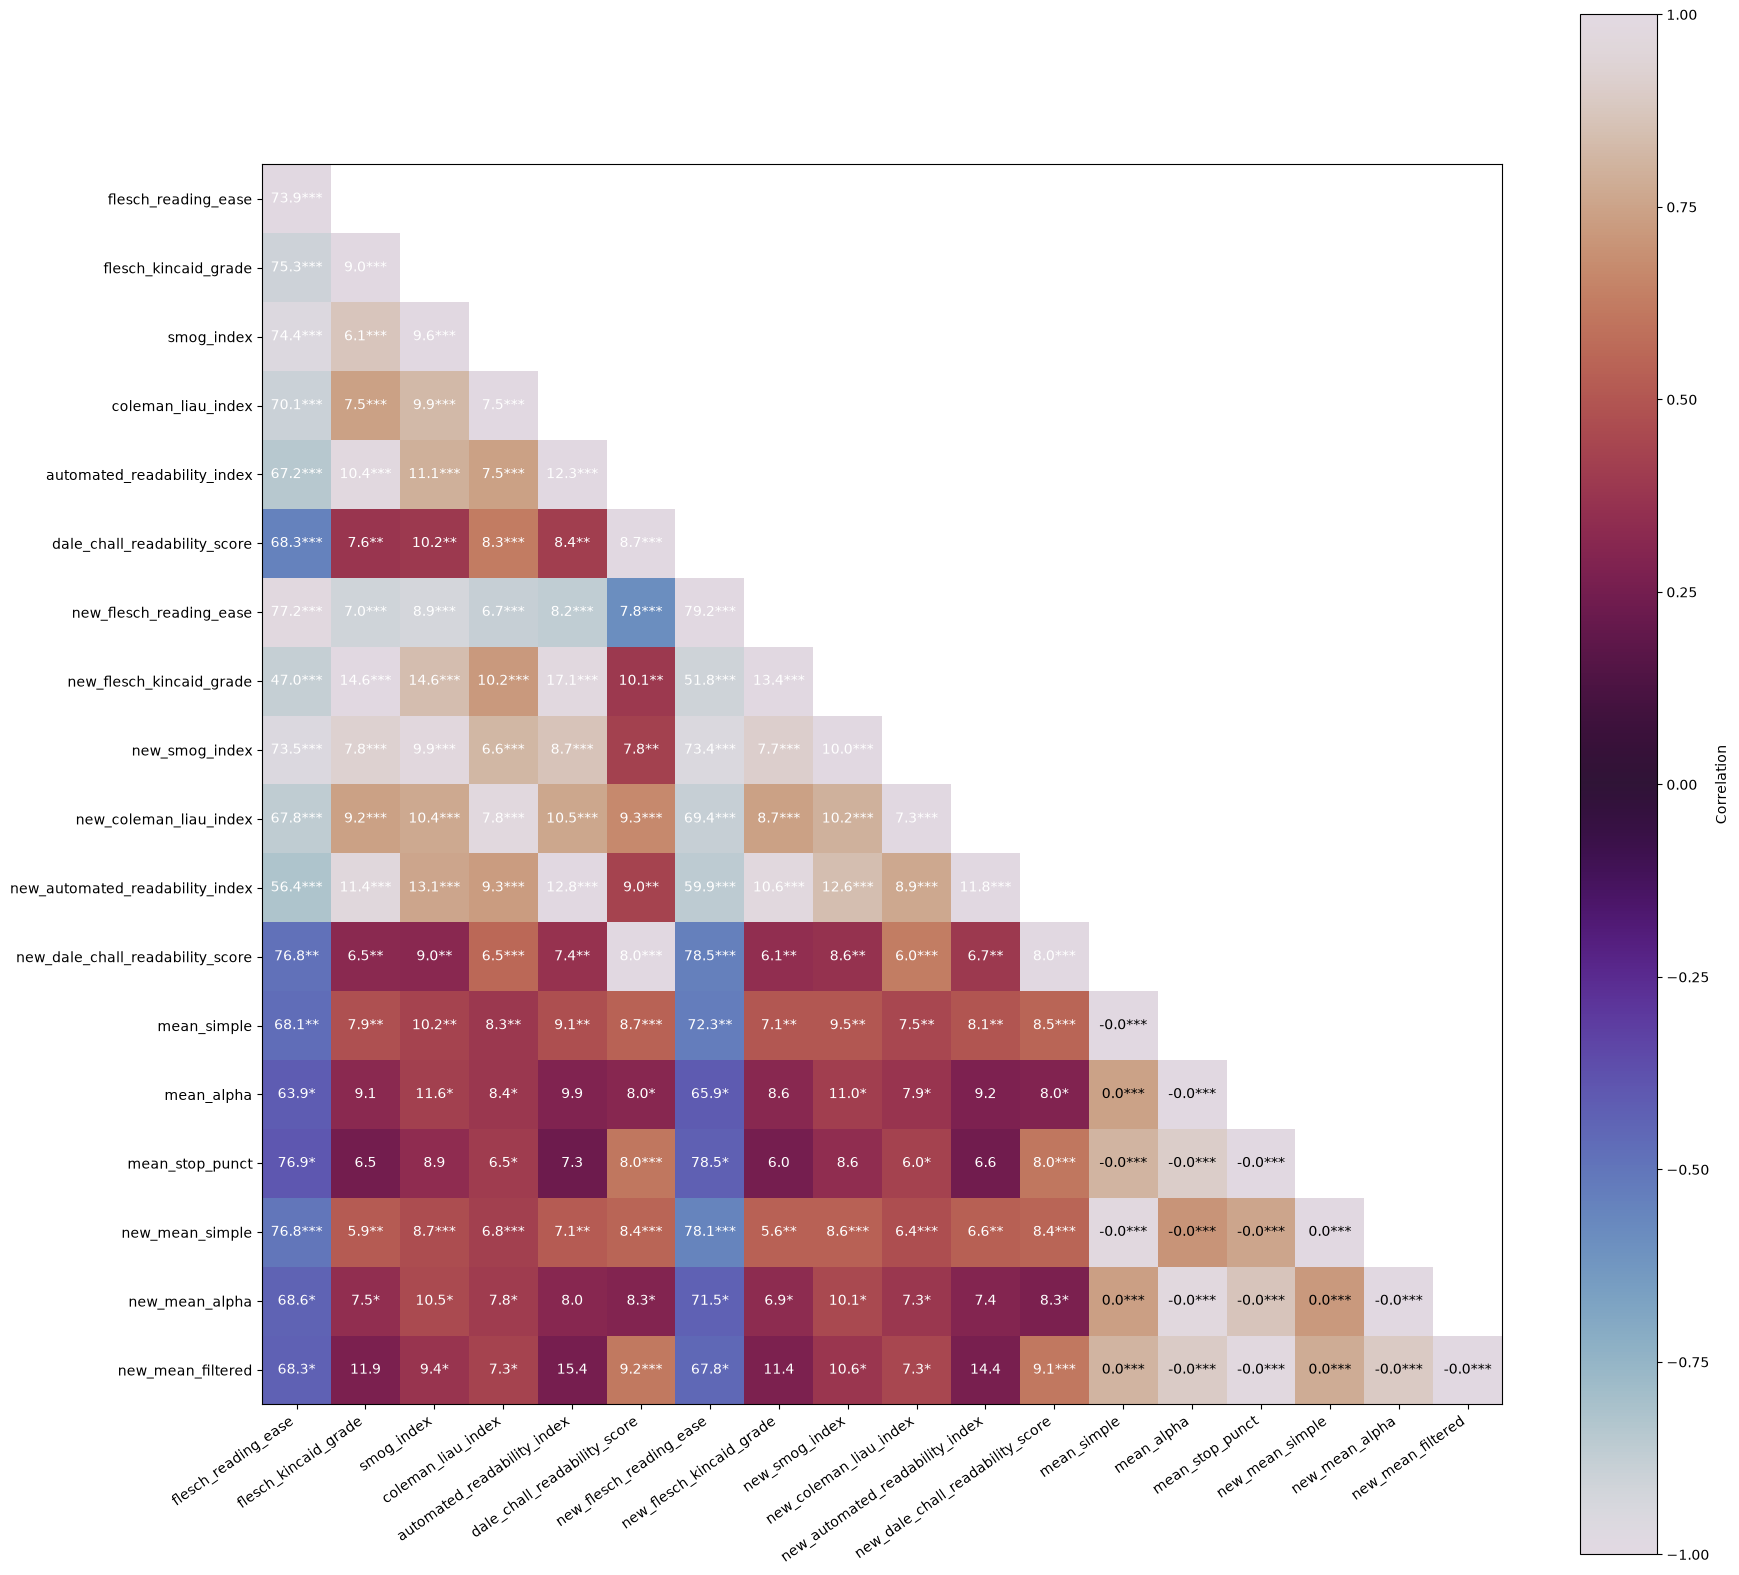

In [51]:
df_mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
corr_masked = np.ma.masked_where(df_mask, corr_df.values)
# return corr_masked

labels = filtered_df.columns

fig, ax = plt.subplots(figsize=(20, 20))
im = ax.imshow(corr_masked, cmap="twilight", vmin=-1, vmax=1)

ax.set_xticks(range(len(labels)), labels=labels, rotation=35, ha="right")
ax.set_yticks(range(len(labels)), labels=labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = filtered_df.iloc[i, j]
        p_val = pval_df.iloc[i,j]
        ax.text(j, i, f"{val:.1f}{p_val}", ha="center", va="center",
                color="white" if abs(val) > 0.6 or type(corr_masked[i,j]) == np.ma.core.MaskedConstant else "black")

fig.colorbar(im, ax=ax, label="Correlation")